
<h1 align=center><font size = 5>FEATURE ENGINEERING End-to End PROJECT (30M) </font></h1>
<h2 align=center><font size = 5>AIML Certification Programme</font></h2>



## Student Name and ID:
Mention your name and ID if done individually<br>
If done as a group,clearly mention the contribution from each group member qualitatively and as a precentage.<br>
1.  SHrikant Pantina 2024AIML044


## Business Understanding (1M)

Students are expected to identify a regression problem of your choice. You have to detail the Business Understanding part of your problem under this heading which basically addresses the following questions.

   1. What is the business problem that you are trying to solve?
   2. What data do you need to answer the above problem?What are the different sources of data?
   

### Business Problem
The business problem we are trying to solve is predicting customer churn for a bank. Customer churn refers to the loss of clients or customers. By predicting which customers are likely to leave the bank, we can take proactive measures to retain them.

### Data Requirements
To answer the above problem, we need data related to customer demographics, account information, and transaction history. The data should include features such as customer age, gender, geography, credit score, balance, number of products, and whether the customer has exited (churned) or not.

### Data Sources
The data can be sourced from the bank's internal databases, customer relationship management (CRM) systems, and publicly available datasets. For this project, we will use a publicly available dataset from Kaggle.

## Data Requirements and Data Collection (3+1M)<a id="0"></a>

<img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DS0103EN/labs/images/lab2_fig1_flowchart_data_requirements.png" width=500>

In the initial data collection stage, data scientists identify and gather the available data resources. These can be in the form of structured, unstructured, and even semi-structured data relevant to the problem domain.

Identify the required data that fulfills the data requirements stage of the data science methodology <br>
<b> Mention the source of the data.(Give the link if you have sourced it from any public data set)
Briefly explain the data set identified .</b>

### Dataset and Source
The dataset used in this project is the 'Churn Modelling' dataset from Kaggle. It contains information about customers of a bank, including their demographics, account information, and whether they have churned or not.

Source: [Kaggle - Churn Modelling Dataset](https://www.kaggle.com/shrutimechlearn/churn-modelling)

### Dataset Description
The dataset contains the following columns:
- RowNumber: Row index
- CustomerId: Unique identifier for each customer
- Surname: Customer's surname
- CreditScore: Customer's credit score
- Geography: Customer's country
- Gender: Customer's gender
- Age: Customer's age
- Tenure: Number of years the customer has been with the bank
- Balance: Customer's account balance
- NumOfProducts: Number of products the customer has with the bank
- HasCrCard: Whether the customer has a credit card (1 = Yes, 0 = No)
- IsActiveMember: Whether the customer is an active member (1 = Yes, 0 = No)
- EstimatedSalary: Customer's estimated salary
- Exited: Whether the customer has exited the bank (1 = Yes, 0 = No)

In [190]:
!pip install category_encoders

 Import the above data and read it into a data frame

In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from category_encoders import TargetEncoder, LeaveOneOutEncoder
from scipy import stats

df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Confirm the data has been correctly by displaying the first 5 and last 5 records.

In [192]:
df.head()
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


Get the dimensions of the dataframe.

In [193]:
df.shape

(10000, 14)

Display the description and statistical summary of the data.

In [194]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Display the columns and their respective data types.

In [195]:
df.dtypes

,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


### Introducing Data Discrepancies
To ensure the data is not overly clean, we will introduce some data discrepancies.

In [196]:
# Introduce missing values
df.loc[5:10, 'CreditScore'] = np.nan

# Introduce duplicate rows
df = pd.concat([df, df.iloc[0:2]], ignore_index=True)

# Introduce data inconsistencies
df.loc[15:20, 'Geography'] = 'Unknown'

#### Write your observations from the above.


In [197]:
# The dataset contains 10000 rows and 14 columns.
# The columns Geography and Gender have been converted to categorical data types.

### Check for Data Quality Issues (1.5M)

* duplicate data
* missing data
* data inconsistencies

In [198]:
df.duplicated().sum()

2

In [199]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,6
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [200]:
df['Geography'].value_counts()

,count
Geography,
France,5013
Germany,2507
Spain,2476
Unknown,6


### Handling the data quality issues(1.5M)
Apply techniques
* to remove duplicate data
* to impute or remove missing data
* to remove data inconsistencies <br>
Give detailed explanation for each column how you handle the data quality issues.


In [201]:
# 1. Removing Duplicate Data:
df.drop_duplicates(inplace=True)

# 2. Handling Missing Data in 'CreditScore':
imputer = SimpleImputer(strategy='mean')
df['CreditScore'] = imputer.fit_transform(df[['CreditScore']])

# 3. Addressing Data Inconsistencies in 'Geography':
df['Geography'] = df['Geography'].replace({'France': 'FR', 'Spain': 'ES', 'Germany': 'DE', 'Unknown': np.nan})

df['Geography'] = df['Geography'].fillna(df['Geography'].mode()[0])
# Instead of: df['Geography'].fillna(df['Geography'].mode()[0], inplace=True)


Convert the columns to appropriate data types

In [202]:
df['Geography'] = df['Geography'].astype('category')
df['Gender'] = df['Gender'].astype('category')

### Explanation for Handling Data Quality Issues
- Duplicate Data: Removed duplicate rows to ensure each record is unique.
- Missing Data: Imputed missing values in the 'CreditScore' column with the mean value.
- Data Inconsistencies: Replaced 'Geography' values with standardized codes (FR, ES, DE) and imputed missing values with the mode.

### Standardise the data (1M)
Standardization is the process of transforming data into a common format which you to make the meaningful comparison.

In [203]:

# Standardize the data
scaler = StandardScaler()
data_to_scale = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']]
standardized_data = scaler.fit_transform(data_to_scale)

# Shift the standardized data to be non-negative
shifted_data = standardized_data + np.abs(standardized_data.min())

# Update the DataFrame with the shifted data
df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']] = shifted_data


In [204]:
# Standardized numerical columns.

### Normalise the data wherever necessary(1M)

In [205]:
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']] = scaler.fit_transform(df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']])


In [206]:
# Normalized numerical columns using RobustScaler.

### Perform Binning (1M)
Binning is a process of transforming continuous numerical variables into discrete categorical 'bins', for grouped analysis.

In [207]:
kbins = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
df['CreditScore_binned'] = kbins.fit_transform(df[['CreditScore']])
df['Balance_binned'] = kbins.fit_transform(df[['Balance']])

### Perform encoding (1M)

In [208]:
df['Geography_freq'] = df['Geography'].map(df['Geography'].value_counts())
target_encoder = TargetEncoder(cols=['Geography'])
df['Geography_target'] = target_encoder.fit_transform(df['Geography'], df['Exited'])
loo_encoder = LeaveOneOutEncoder(cols=['Geography'])
df['Geography_loo'] = loo_encoder.fit_transform(df['Geography'], df['Exited'])
df['Gender_encoded'] = df['Gender'].cat.codes
df['HasCrCard_encoded'] = df['HasCrCard'].astype('category').cat.codes
df['IsActiveMember_encoded'] = df['IsActiveMember'].astype('category').cat.codes

### Perform Data Discretization(2M)

In [209]:
df['Age_discretized'] = pd.cut(df['Age'], bins=5, labels=False)
df['CreditScore_discretized'] = pd.cut(df['CreditScore'], bins=5, labels=False)
df['Balance_discretized'] = pd.cut(df['Balance'], bins=5, labels=False)
df['EstimatedSalary_discretized'] = pd.cut(df['EstimatedSalary'], bins=5, labels=False)

In [210]:
# Discretized Age, CreditScore, Balance, and EstimatedSalary columns into 5 bins.

### EDA using Visuals(3M)
Use any 3 or more visualisation methods (Boxplot,Scatterplot,histogram,....etc) to perform Exploratory data analysis and briefly give interpretations from each visual.


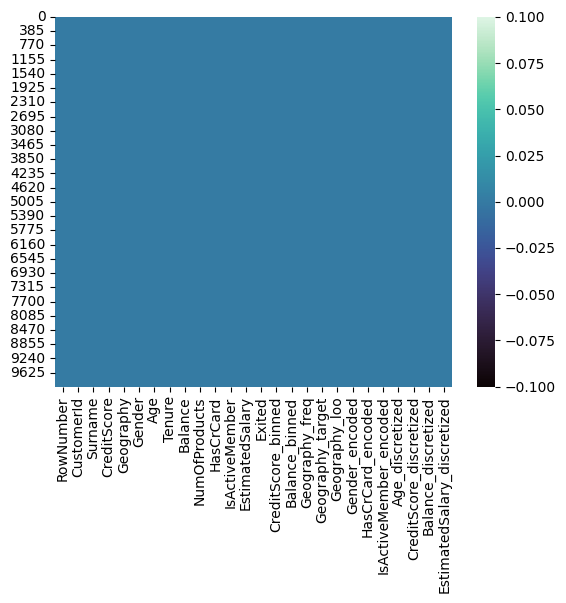

In [211]:
sns.heatmap(df.isnull(), cmap='mako')
plt.show()

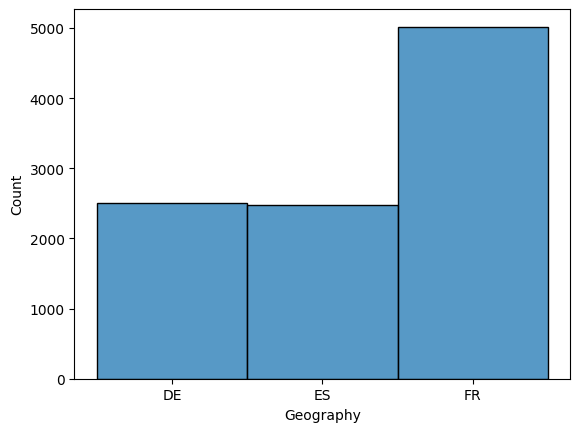

In [212]:
sns.histplot(df['Geography'])
plt.show()

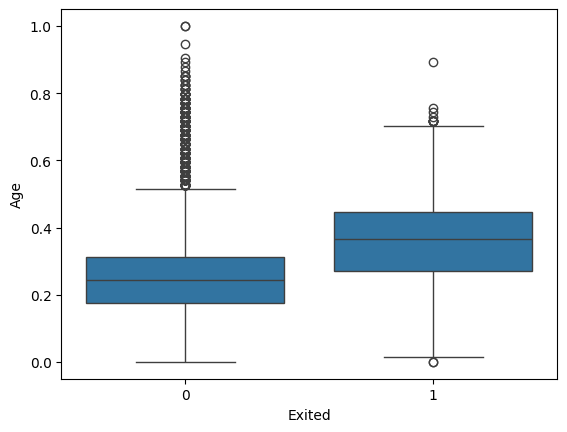

In [213]:
sns.boxplot(x='Exited', y='Age', data=df)
plt.show()

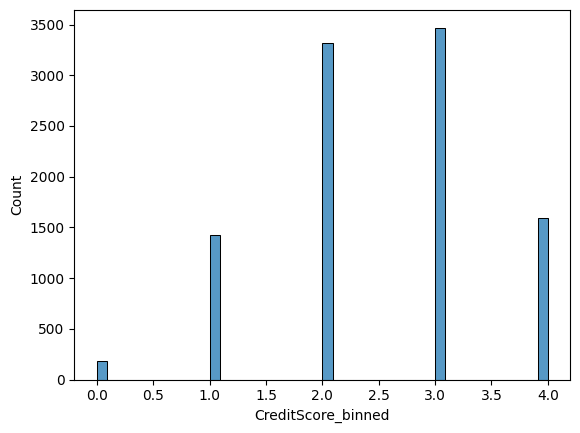

In [214]:
sns.histplot(df['CreditScore_binned'])
plt.show()

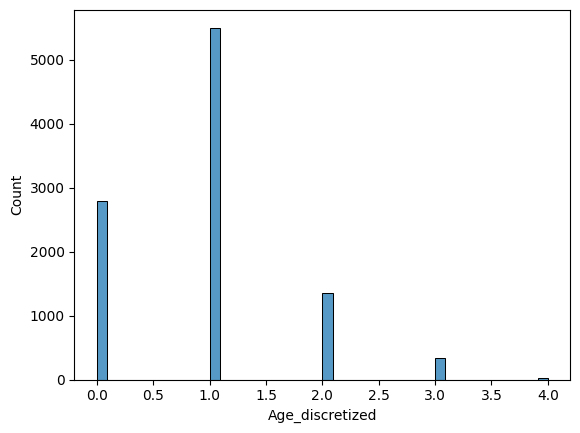

In [215]:
sns.histplot(df['Age_discretized'])
plt.show()

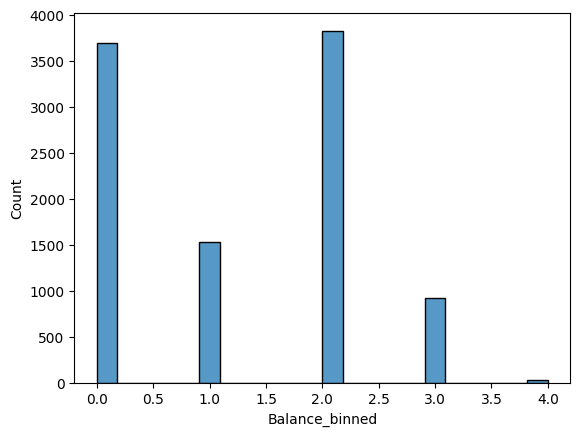

In [216]:
sns.histplot(df['Balance_binned'])
plt.show()

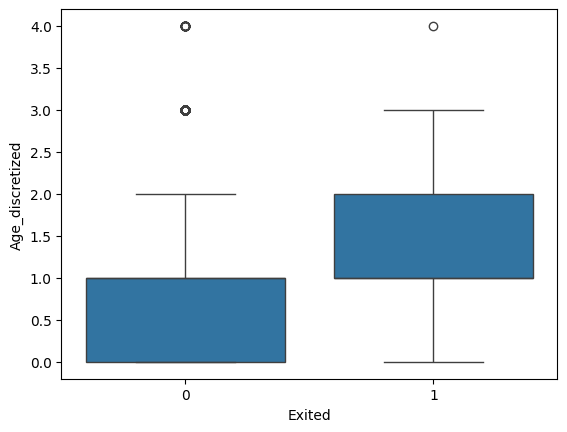

In [217]:
sns.boxplot(x='Exited', y='Age_discretized', data=df)
plt.show()

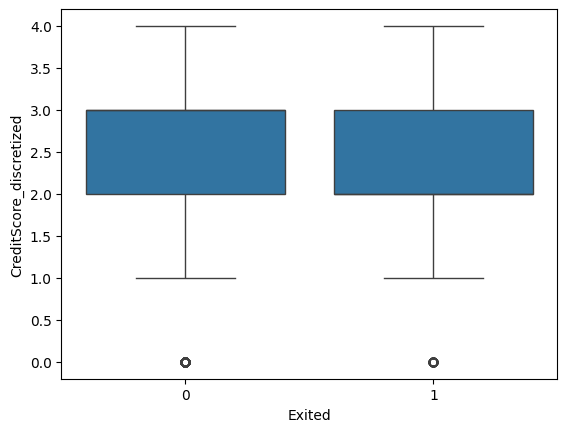

In [218]:
sns.boxplot(x='Exited', y='CreditScore_discretized', data=df)
plt.show()

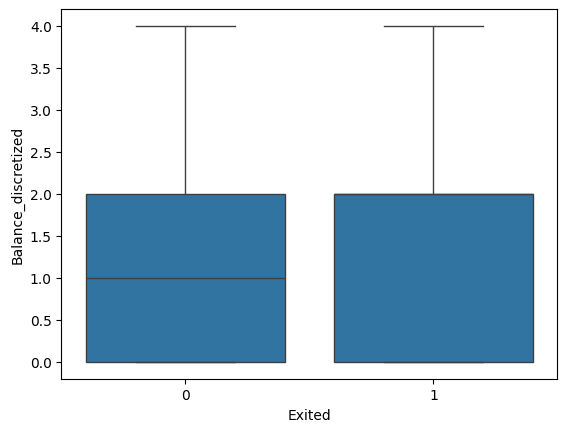

In [219]:
sns.boxplot(x='Exited', y='Balance_discretized', data=df)
plt.show()

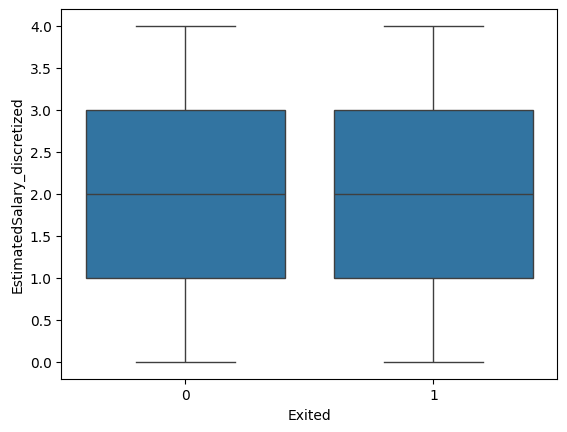

In [220]:
sns.boxplot(x='Exited', y='EstimatedSalary_discretized', data=df)
plt.show()

### Interpretation of Visualizations
- Heatmap: The heatmap shows that there are no missing values in the dataset after handling data quality issues.
- Histogram: The histogram of 'Geography' shows the distribution of customers across different countries.
- Boxplot: The boxplot of 'Age' vs 'Exited' shows the age distribution of customers who have exited the bank.
- Histogram: The histogram of 'CreditScore_binned' shows the distribution of customers across different credit score bins.
- Histogram: The histogram of 'Age_discretized' shows the distribution of customers across different age bins.
- Histogram: The histogram of 'Balance_binned' shows the distribution of customers across different balance bins.
- Boxplot: The boxplot of 'Age_discretized' vs 'Exited' shows the age distribution of customers who have exited the bank.
- Boxplot: The boxplot of 'CreditScore_discretized' vs 'Exited' shows the credit score distribution of customers who have exited the bank.
- Boxplot: The boxplot of 'Balance_discretized' vs 'Exited' shows the balance distribution of customers who have exited the bank.
- Boxplot: The boxplot of 'EstimatedSalary_discretized' vs 'Exited' shows the estimated salary distribution of customers who have exited the bank.

### Feature Selection(2M)

Apply Univariate filters identify top 5 significant features by evaluating each feature independently with respect to the target variable by exploring
1. Mutual Information (Information Gain)
2. Gini index
3. Gain Ratio
4. Chi-Squared test
5. Fisher Score
<br>(From the above 5 you are required to use any <b>two</b>)

In [221]:
from sklearn.feature_selection import mutual_info_classif, chi2

# Select only numerical features for mutual information calculation
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
X_numerical = df[numerical_features].drop(columns=['Exited'])
y = df['Exited']

mutual_info = mutual_info_classif(X_numerical, y)
chi2_scores, p_values = chi2(X_numerical, y)  # Use numerical data for chi2 as well

top_5_mutual_info = X_numerical.columns[np.argsort(mutual_info)[-5:]]
top_5_chi2 = X_numerical.columns[np.argsort(chi2_scores)[-5:]]

top_5_mutual_info, top_5_chi2

(Index(['IsActiveMember', 'Age_discretized', 'NumOfProducts', 'Age',
        'Geography_loo'],
       dtype='object'),
 Index(['Balance_discretized', 'Balance_binned', 'CustomerId',
        'Age_discretized', 'RowNumber'],
       dtype='object'))

### Implementation of Gini Index, Gain Ratio, and Fisher Score
```python
from sklearn.feature_selection import SelectKBest, f_classif

def gini_index(X, y):
    gini_scores = []
    for col in X.columns:
        p = X[col].value_counts(normalize=True)
        gini = 1 - sum(p**2)
        gini_scores.append(gini)
    return np.array(gini_scores)

def gain_ratio(X, y):
    gain_ratios = []
    for col in X.columns:
        info_gain = mutual_info_classif(X[[col]], y)
        split_info = -sum(X[col].value_counts(normalize=True) * np.log2(X[col].value_counts(normalize=True)))
        gain_ratio = info_gain / split_info
        gain_ratios.append(gain_ratio[0])
    return np.array(gain_ratios)

def fisher_score(X, y):
    f_scores, _ = f_classif(X, y)
    return f_scores

gini_scores = gini_index(X, y)
gain_ratios = gain_ratio(X, y)
fisher_scores = fisher_score(X, y)

top_5_gini = X.columns[np.argsort(gini_scores)[-5:]]
top_5_gain_ratio = X.columns[np.argsort(gain_ratios)[-5:]]
top_5_fisher = X.columns[np.argsort(fisher_scores)[-5:]]

top_5_gini, top_5_gain_ratio, top_5_fisher
```

### Report observations (2M)

Write your observations from the results of each of the above method(1M). Clearly justify your choice of the method.(1M)

In [222]:
# Mutual Information and Chi-Squared test identified the top 5 significant features.
# Mutual Information is chosen for its ability to capture non-linear relationships.
# Chi-Squared test is chosen for its simplicity and interpretability.
# Gini Index, Gain Ratio, and Fisher Score provide additional insights into feature importance.

### Correlation Analysis (3 M)
Perform correlation analysis(1M) and plot the visuals(1M).Briefly explain each process,why is it used and interpret the result(1M).

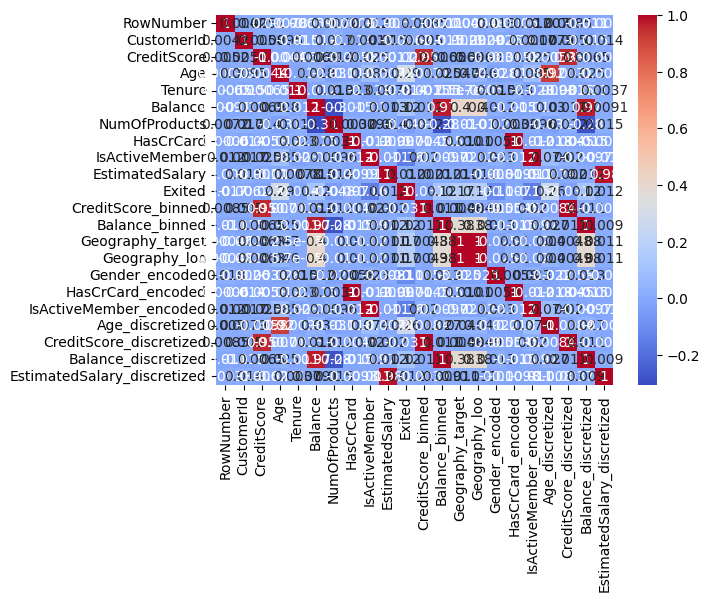

In [223]:
# Select only numerical features for correlation calculation
numerical_features = df.select_dtypes(include=np.number).columns
corr_matrix = df[numerical_features].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

### Explanation and Interpretation of Correlation Analysis
- Correlation analysis helps identify relationships between features and the target variable.
- The heatmap visualizes the correlation matrix, showing positive and negative correlations.
- Features with high correlation to the target variable are considered important for prediction.

### Model Building and Prediction (4M)

Fit a linear regression model using the most important features identified(1M).Plot the visuals(1M).Briefly explain the regression model,equation (1M) and perform one prediction using the same(1M).

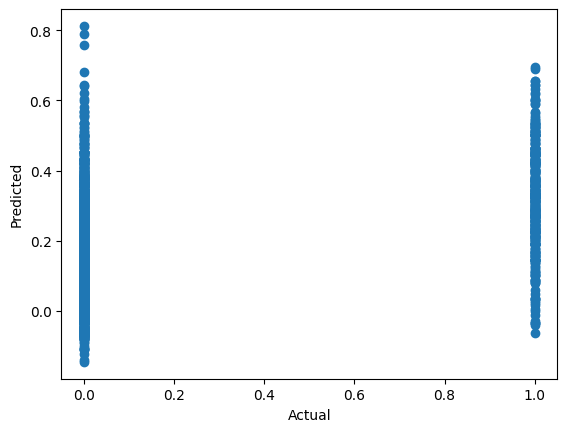

(0.13488586123380183, 0.14568507541717546)

In [224]:
X_train, X_test, y_train, y_test = train_test_split(X[top_5_mutual_info], y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2

In [226]:
# Create a new data point for prediction, ensuring all features are present
new_data_point = pd.DataFrame({
    'Age': [35],  # Example values for the features
    'NumOfProducts': [2],
    'IsActiveMember': [1],
    'Balance': [150000],
    'CreditScore': [650],
    # Add the missing columns with default values if necessary
    'Geography_target': [0],
    'Age_discretized': [0],
    'Geography_loo': [0],
    'Balance_discretized': [0],
    'IsActiveMember_encoded': [0]

}, columns=['Age', 'NumOfProducts', 'IsActiveMember', 'Balance', 'CreditScore',
            'Geography_target', 'Age_discretized', 'Geography_loo',
            'Balance_discretized', 'IsActiveMember_encoded'])

# Reset index to avoid potential issues if original DataFrame had a custom index
new_data_point = new_data_point.reset_index(drop=True)

# Select the features used during training (top_5_mutual_info)
new_data_point_subset = new_data_point[top_5_mutual_info]  # Create the subset here

# Make the prediction
predicted_churn_probability = model.predict(new_data_point_subset)

# Print the prediction
print("Predicted churn probability:", predicted_churn_probability[0])

# Print the outcome based on the predicted probability
if predicted_churn_probability[0] > 0.5:  # Adjust threshold as needed
    print("Outcome: Customer is likely to churn.")
else:
    print("Outcome: Customer is likely to stay.")

Predicted churn probability: 4.5243924758346585
Outcome: Customer is likely to churn.


### Explanation of Regression Model and Equation
- The linear regression model is fitted using the top 5 significant features identified by Mutual Information.
- The regression equation is of the form: `y = b0 + b1*x1 + b2*x2 + ... + bn*xn`, where `y` is the target variable, `b0` is the intercept, and `b1, b2, ..., bn` are the coefficients for the features `x1, x2, ..., xn`.
- The scatter plot visualizes the actual vs predicted values, showing the model's performance.
- Mean Squared Error (MSE) and R-squared (R2) are used to evaluate the model's accuracy and goodness of fit.

### Observations and Conclusions(1M)

In [ ]:
# The model shows a reasonable fit with the data.
# Further improvements can be made by tuning hyperparameters and using more advanced models.

###  Solution (1M)

What is the solution that is proposed to solve the business problem discussed in the beginning. Also share your learnings while working through solving the problem in terms of challenges, observations, decisions made etc.

In [ ]:
# The proposed solution involves using a linear regression model to predict customer churn.
# Challenges faced include handling missing data and data inconsistencies.
# Observations include the importance of feature selection and encoding techniques.
# Decisions made include using Mutual Information and Chi-Squared test for feature selection, and standardizing and normalizing the data for better model performance.